# 64 - SigLIP 2 JS 埋め込み（Python vs JS 比較）

## 概要
SigLIP 2 の ONNX モデルを Transformers.js (Node.js) で実行し、
Python (PyTorch) との埋め込みの類似度を比較する。

## 比較ポイント
1. **Python vs JS 画像埋め込み**のコサイン類似度
   - SigLIP 1 では mean 0.906（PIL vs Sharp の前処理差異）
2. **量子化バリエーション**: fp32, fp16, q8, q4
3. **処理速度**: Node.js (CPU) vs Python (GPU)

## ONNX モデル
- `onnx-community/siglip2-base-patch16-224-ONNX`

## 前提
- Notebook 61 で Python 側の SigLIP 2 埋め込みが DuckDB に保存済み
- JS スクリプト: `js/embed_images_siglip2.mjs`, `js/embed_texts_siglip2.mjs`

In [1]:
import json
import os
import subprocess
import tempfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance

## 1. 環境設定

In [2]:
# nvm の Node.js パスを追加
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

# 動作確認
result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js version: {result.stdout.strip()}")

# パス設定
DB_PATH = Path("../data/images.duckdb")
JS_DIR = Path("../js")
PYTHON_MODEL = "google/siglip2-base-patch16-224"
JS_MODEL = "onnx-community/siglip2-base-patch16-224-ONNX"

Node.js version: v24.13.1


## 2. Python 側の埋め込みを読み込み

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)

# 画像カタログ
catalog_df = conn.execute("""
    SELECT id, file_path, category
    FROM image_catalog
    ORDER BY id
""").fetchdf()

# Python 埋め込み
py_emb_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [PYTHON_MODEL]).fetchdf()

conn.close()

print(f"Images: {len(catalog_df)}")
print(f"Python embeddings: {len(py_emb_df)}")

if len(py_emb_df) == 0:
    raise ValueError(f"No embeddings found for {PYTHON_MODEL}. Run notebook 61 first.")

# Python 埋め込みを辞書に変換
py_embeddings = {}
for _, row in py_emb_df.iterrows():
    py_embeddings[row['id']] = np.array(row['embedding'], dtype=np.float32)

Images: 378
Python embeddings: 378


## 3. 画像リスト JSON を生成

In [4]:
# JS スクリプト用の画像リスト JSON
image_list = []
for _, row in catalog_df.iterrows():
    image_list.append({"id": row["id"], "file_path": row["file_path"]})

image_list_path = Path(tempfile.mktemp(suffix=".json"))
with open(image_list_path, "w") as f:
    json.dump(image_list, f)

print(f"Image list written to: {image_list_path}")
print(f"Total images: {len(image_list)}")

Image list written to: /tmp/tmp66638a_9.json
Total images: 378


## 4. JS で画像埋め込みを生成（各 dtype）

In [5]:
dtypes = ["fp32", "fp16", "q8", "q4"]
js_results = {}

for dtype in dtypes:
    print(f"\n{'='*50}")
    print(f"Running JS embedding with dtype={dtype}...")
    print(f"{'='*50}")
    
    output_path = Path(tempfile.mktemp(suffix=f"_siglip2_{dtype}.json"))
    
    cmd = [
        "node", str(JS_DIR / "embed_images_siglip2.mjs"),
        "--image-list", str(image_list_path),
        "--output", str(output_path),
        "--dtype", dtype,
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True, cwd=str(JS_DIR))
    print(result.stderr)
    
    if result.returncode != 0:
        print(f"ERROR: JS process failed with return code {result.returncode}")
        continue
    
    # 結果の読み込み
    with open(output_path) as f:
        js_output = json.load(f)
    
    js_results[dtype] = js_output
    print(f"  Model: {js_output['model']}")
    print(f"  Count: {js_output['count']}")
    print(f"  Time: {js_output['processing_time_seconds']}s")
    
    # クリーンアップ
    output_path.unlink(missing_ok=True)

# 画像リストファイルのクリーンアップ
image_list_path.unlink(missing_ok=True)

print(f"\n\nCompleted dtypes: {list(js_results.keys())}")


Running JS embedding with dtype=fp32...


Model: onnx-community/siglip2-base-patch16-224-ONNX
dtype: fp32
Images to process: 378
Loading model and processor...
Model loaded in 1.0s
  [10/378] 2.8s elapsed (3.6 img/s)
  [20/378] 5.5s elapsed (3.6 img/s)
  [30/378] 8.6s elapsed (3.5 img/s)
  [40/378] 11.6s elapsed (3.4 img/s)
  [50/378] 14.5s elapsed (3.4 img/s)
  [60/378] 17.1s elapsed (3.5 img/s)
  [70/378] 20.3s elapsed (3.4 img/s)
  [80/378] 23.3s elapsed (3.4 img/s)
  [90/378] 26.1s elapsed (3.4 img/s)
  [100/378] 29.2s elapsed (3.4 img/s)
  [110/378] 32.0s elapsed (3.4 img/s)
  [120/378] 35.2s elapsed (3.4 img/s)
  [130/378] 38.2s elapsed (3.4 img/s)
  [140/378] 41.3s elapsed (3.4 img/s)
  [150/378] 44.2s elapsed (3.4 img/s)
  [160/378] 47.2s elapsed (3.4 img/s)
  [170/378] 50.5s elapsed (3.4 img/s)
  [180/378] 53.4s elapsed (3.4 img/s)
  [190/378] 56.5s elapsed (3.4 img/s)
  [200/378] 59.4s elapsed (3.4 img/s)
  [210/378] 62.4s elapsed (3.4 img/s)
  [220/378] 65.4s elapsed (3.4 img/s)
  [230/378] 68.3s elapsed (3.4 img/s)

Model: onnx-community/siglip2-base-patch16-224-ONNX
dtype: fp16
Images to process: 378
Loading model and processor...
Model loaded in 16.9s
  [10/378] 3.6s elapsed (2.8 img/s)
  [20/378] 6.5s elapsed (3.1 img/s)
  [30/378] 9.7s elapsed (3.1 img/s)
  [40/378] 12.8s elapsed (3.1 img/s)
  [50/378] 16.0s elapsed (3.1 img/s)
  [60/378] 19.2s elapsed (3.1 img/s)
  [70/378] 22.5s elapsed (3.1 img/s)
  [80/378] 25.8s elapsed (3.1 img/s)
  [90/378] 28.9s elapsed (3.1 img/s)
  [100/378] 32.2s elapsed (3.1 img/s)
  [110/378] 35.4s elapsed (3.1 img/s)
  [120/378] 38.9s elapsed (3.1 img/s)
  [130/378] 42.4s elapsed (3.1 img/s)
  [140/378] 45.9s elapsed (3.1 img/s)
  [150/378] 49.3s elapsed (3.0 img/s)
  [160/378] 52.8s elapsed (3.0 img/s)
  [170/378] 56.4s elapsed (3.0 img/s)
  [180/378] 59.7s elapsed (3.0 img/s)
  [190/378] 63.3s elapsed (3.0 img/s)
  [200/378] 66.4s elapsed (3.0 img/s)
  [210/378] 69.7s elapsed (3.0 img/s)
  [220/378] 73.0s elapsed (3.0 img/s)
  [230/378] 76.3s elapsed (3.0 img/s

Model: onnx-community/siglip2-base-patch16-224-ONNX
dtype: q8
Images to process: 378
Loading model and processor...
Model loaded in 9.2s
  [10/378] 2.6s elapsed (3.8 img/s)
  [20/378] 5.0s elapsed (4.0 img/s)
  [30/378] 7.7s elapsed (3.9 img/s)
  [40/378] 10.3s elapsed (3.9 img/s)
  [50/378] 12.9s elapsed (3.9 img/s)
  [60/378] 15.2s elapsed (3.9 img/s)
  [70/378] 18.0s elapsed (3.9 img/s)
  [80/378] 20.7s elapsed (3.9 img/s)
  [90/378] 23.1s elapsed (3.9 img/s)
  [100/378] 25.9s elapsed (3.9 img/s)
  [110/378] 28.2s elapsed (3.9 img/s)
  [120/378] 30.9s elapsed (3.9 img/s)
  [130/378] 33.6s elapsed (3.9 img/s)
  [140/378] 36.3s elapsed (3.9 img/s)
  [150/378] 38.8s elapsed (3.9 img/s)
  [160/378] 41.6s elapsed (3.8 img/s)
  [170/378] 44.5s elapsed (3.8 img/s)
  [180/378] 47.1s elapsed (3.8 img/s)
  [190/378] 50.0s elapsed (3.8 img/s)
  [200/378] 52.6s elapsed (3.8 img/s)
  [210/378] 55.2s elapsed (3.8 img/s)
  [220/378] 58.0s elapsed (3.8 img/s)
  [230/378] 60.6s elapsed (3.8 img/s)
 

Model: onnx-community/siglip2-base-patch16-224-ONNX
dtype: q4
Images to process: 378
Loading model and processor...
Model loaded in 6.4s
  [10/378] 2.7s elapsed (3.7 img/s)
  [20/378] 5.4s elapsed (3.7 img/s)
  [30/378] 8.4s elapsed (3.6 img/s)
  [40/378] 11.2s elapsed (3.6 img/s)
  [50/378] 13.9s elapsed (3.6 img/s)
  [60/378] 16.6s elapsed (3.6 img/s)
  [70/378] 19.6s elapsed (3.6 img/s)
  [80/378] 22.6s elapsed (3.5 img/s)
  [90/378] 25.2s elapsed (3.6 img/s)
  [100/378] 28.3s elapsed (3.5 img/s)
  [110/378] 31.0s elapsed (3.5 img/s)
  [120/378] 34.1s elapsed (3.5 img/s)
  [130/378] 37.1s elapsed (3.5 img/s)
  [140/378] 40.2s elapsed (3.5 img/s)
  [150/378] 43.0s elapsed (3.5 img/s)
  [160/378] 46.0s elapsed (3.5 img/s)
  [170/378] 49.1s elapsed (3.5 img/s)
  [180/378] 51.9s elapsed (3.5 img/s)
  [190/378] 55.0s elapsed (3.5 img/s)
  [200/378] 57.8s elapsed (3.5 img/s)
  [210/378] 60.6s elapsed (3.5 img/s)
  [220/378] 63.6s elapsed (3.5 img/s)
  [230/378] 66.4s elapsed (3.5 img/s)
 

## 5. Python vs JS コサイン類似度の比較

In [6]:
comparison_results = {}

for dtype, js_output in js_results.items():
    similarities = []
    
    # JS 埋め込みを辞書に変換
    js_embeddings = {}
    for item in js_output['embeddings']:
        js_embeddings[item['id']] = np.array(item['embedding'], dtype=np.float32)
    
    # 各画像のコサイン類似度を計算
    for image_id in py_embeddings:
        if image_id in js_embeddings:
            py_emb = py_embeddings[image_id]
            js_emb = js_embeddings[image_id]
            # cosine_distance = 1 - cosine_similarity
            sim = 1.0 - cosine_distance(py_emb, js_emb)
            similarities.append(sim)
    
    sims = np.array(similarities)
    comparison_results[dtype] = {
        'mean': sims.mean(),
        'std': sims.std(),
        'min': sims.min(),
        'max': sims.max(),
        'median': np.median(sims),
        'count': len(sims),
        'processing_time': js_output['processing_time_seconds'],
    }

# 結果テーブル
print("=" * 80)
print("Python vs JS 画像埋め込みコサイン類似度 (SigLIP 2)")
print("=" * 80)

print(f"\n{'dtype':<8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Median':>8} {'Time(s)':>10}")
print("-" * 62)
for dtype, r in comparison_results.items():
    print(f"{dtype:<8} {r['mean']:>8.4f} {r['std']:>8.4f} {r['min']:>8.4f} {r['max']:>8.4f} {r['median']:>8.4f} {r['processing_time']:>10.1f}")

# SigLIP 1 との比較
print(f"\n--- SigLIP 1 の結果（参考）---")
print(f"SigLIP 1 fp32: mean=0.906, std=0.053")
print(f"CLIP-L fp32: image mean=0.872")

Python vs JS 画像埋め込みコサイン類似度 (SigLIP 2)

dtype        Mean      Std      Min      Max   Median    Time(s)
--------------------------------------------------------------
fp32       0.9235   0.0441   0.7804   0.9991   0.9397      112.8
fp16       0.9236   0.0441   0.7807   0.9991   0.9397      126.0
q8         0.7503   0.0722   0.5408   0.9304   0.7509       99.2
q4         0.9017   0.0421   0.7536   0.9818   0.9112      109.9

--- SigLIP 1 の結果（参考）---
SigLIP 1 fp32: mean=0.906, std=0.053
CLIP-L fp32: image mean=0.872


## 6. 量子化の影響分析

In [7]:
if len(js_results) >= 2:
    # fp32 vs 各量子化レベルの JS 埋め込み間の類似度
    print("=" * 60)
    print("量子化の影響: fp32 vs 各 dtype（JS 内の比較）")
    print("=" * 60)
    
    if 'fp32' in js_results:
        fp32_embs = {item['id']: np.array(item['embedding'], dtype=np.float32)
                     for item in js_results['fp32']['embeddings']}
        
        for dtype in ['fp16', 'q8', 'q4']:
            if dtype not in js_results:
                continue
            other_embs = {item['id']: np.array(item['embedding'], dtype=np.float32)
                         for item in js_results[dtype]['embeddings']}
            
            sims = []
            for img_id in fp32_embs:
                if img_id in other_embs:
                    sim = 1.0 - cosine_distance(fp32_embs[img_id], other_embs[img_id])
                    sims.append(sim)
            
            sims = np.array(sims)
            print(f"  fp32 vs {dtype}: mean={sims.mean():.6f}, std={sims.std():.6f}, min={sims.min():.6f}")
else:
    print("Not enough dtype results for quantization comparison.")

量子化の影響: fp32 vs 各 dtype（JS 内の比較）
  fp32 vs fp16: mean=0.999997, std=0.000019, min=0.999622
  fp32 vs q8: mean=0.772013, std=0.064738, min=0.599421
  fp32 vs q4: mean=0.964818, std=0.012462, min=0.912472


## 7. 可視化

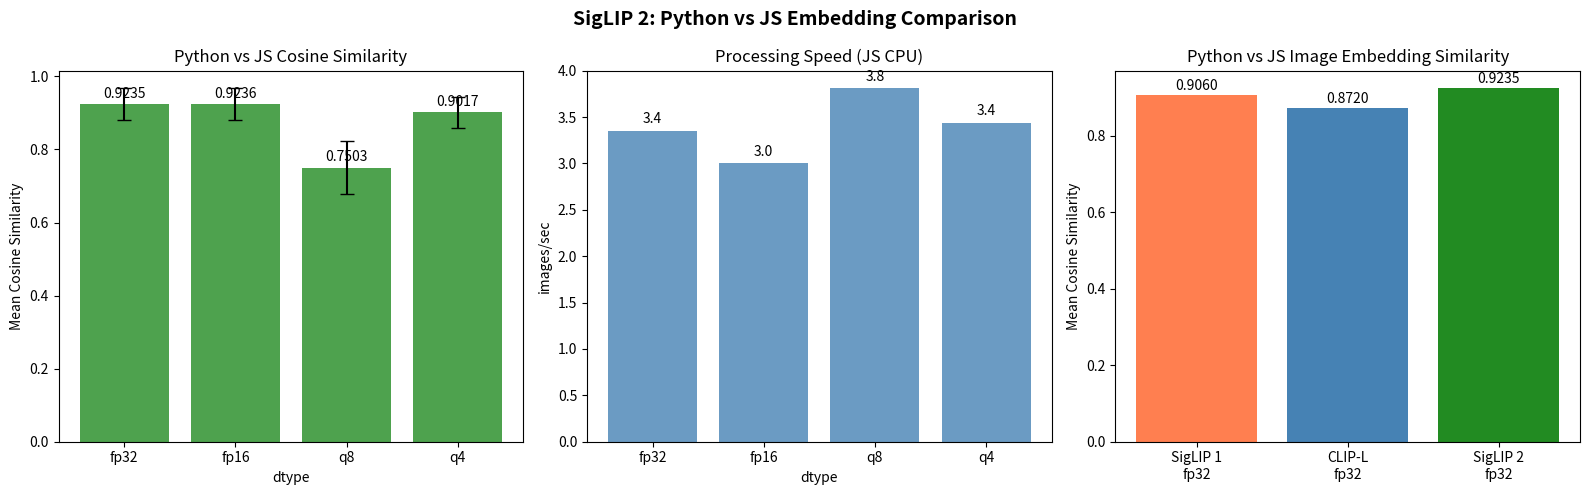

Saved: data/siglip2_python_vs_js.png


In [8]:
if comparison_results:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    dtype_names = list(comparison_results.keys())
    
    # 1. Mean cosine similarity by dtype
    ax = axes[0]
    means = [comparison_results[d]['mean'] for d in dtype_names]
    stds = [comparison_results[d]['std'] for d in dtype_names]
    bars = ax.bar(dtype_names, means, yerr=stds, capsize=5, color='forestgreen', alpha=0.8)
    ax.set_title('Python vs JS Cosine Similarity')
    ax.set_ylabel('Mean Cosine Similarity')
    ax.set_xlabel('dtype')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    # 2. Processing time by dtype
    ax = axes[1]
    times = [comparison_results[d]['processing_time'] for d in dtype_names]
    speeds = [len(py_embeddings) / t for t in times]
    bars = ax.bar(dtype_names, speeds, color='steelblue', alpha=0.8)
    ax.set_title('Processing Speed (JS CPU)')
    ax.set_ylabel('images/sec')
    ax.set_xlabel('dtype')
    for bar, val in zip(bars, speeds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    
    # 3. Comparison with SigLIP 1
    ax = axes[2]
    models = ['SigLIP 1\nfp32', 'CLIP-L\nfp32', 'SigLIP 2\nfp32']
    siglip2_mean = comparison_results.get('fp32', {}).get('mean', 0)
    model_sims = [0.906, 0.872, siglip2_mean]
    colors = ['coral', 'steelblue', 'forestgreen']
    bars = ax.bar(models, model_sims, color=colors)
    ax.set_title('Python vs JS Image Embedding Similarity')
    ax.set_ylabel('Mean Cosine Similarity')
    for bar, val in zip(bars, model_sims):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.suptitle('SigLIP 2: Python vs JS Embedding Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/siglip2_python_vs_js.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: data/siglip2_python_vs_js.png')
else:
    print("No JS results available for visualization.")

## 8. 結果の保存

In [9]:
from datetime import datetime

output_data = {
    "timestamp": datetime.now().isoformat(),
    "python_model": PYTHON_MODEL,
    "js_model": JS_MODEL,
    "comparison_results": comparison_results,
    "reference": {
        "siglip1_fp32_mean": 0.906,
        "clip_l_fp32_mean": 0.872,
    },
}

output_path = Path("../data/evaluations") / f"siglip2_python_vs_js_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/siglip2_python_vs_js_2026-02-16.json


## まとめ・評価・考察

SigLIP 2 の Python (PyTorch) vs JS (ONNX/Transformers.js) 画像埋め込み比較を実施した。

### 実験結果

| dtype | Mean cos sim | Std | Min | Max | 処理速度 (img/s) |
|-------|:---:|:---:|:---:|:---:|:---:|
| **fp32** | **0.9235** | 0.0441 | 0.7804 | 0.9991 | 3.4 |
| **fp16** | **0.9236** | 0.0441 | 0.7807 | 0.9991 | 3.0 |
| **q8** | 0.7503 | 0.0722 | 0.5408 | 0.9304 | 3.8 |
| **q4** | 0.9017 | 0.0421 | 0.7536 | 0.9818 | 3.5 |

**量子化の内部比較 (JS fp32 vs 各 dtype)**:
- fp32 vs fp16: 0.999997（ほぼ同一）
- fp32 vs q8: 0.772（大幅劣化）
- fp32 vs q4: 0.965（中程度の差異）

### 考察

1. **SigLIP 2 fp32 の Python-JS 類似度は 0.924 で SigLIP 1 (0.906) より高い**
   - PIL (Python) と Sharp (JS) の画像前処理の差異があっても、0.924 の高い類似度
   - CLIP-L (0.872) よりも大幅に高い互換性
   - → SigLIP 2 は Python で事前計算、JS で検索というユースケースに適している

2. **fp16 は fp32 と実質同一** (0.9236 vs 0.9235)
   - メモリ半分で品質劣化なし。実用では fp16 が推奨

3. **q8 量子化が異常に低い (0.750)**
   - SigLIP 1 の q8 は 0.885 だったが、SigLIP 2 では 0.750 に大幅低下
   - q4 (0.902) より q8 が悪いのは異常
   - ONNX 変換時の q8 量子化に問題がある可能性（`onnx-community` 提供の int8 モデルの品質）
   - JS 内の fp32 vs q8 も 0.772 と内部的にも大きな差異
   - **結論: SigLIP 2 の q8 は使用すべきでない**

4. **q4 は実用的な品質** (0.902)
   - 0.9 を超えており、モデルサイズ削減の効果を考えると許容範囲
   - 速度面でも fp32 と同程度

5. **処理速度は 3.0-3.8 img/s (Node.js CPU)**
   - SigLIP 1 との速度差は小さい
   - Python GPU (4.2 img/s) と比較しても差は小さく、Node.js でも十分実用的

### JS スクリプトに関する技術的知見

- SigLIP 2 は Transformers.js で `model_type: "siglip"` として認識される
- `AutoModel` ではなく **`SiglipVisionModel`** を使用する必要がある
- `model.get_image_features()` は利用不可。`model(inputs)` → `pooler_output` を取得

テキスト埋め込みの比較（特に日本語トークナイザー）は Notebook 65 で行う。